In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import random
import scipy

sc.set_figure_params(dpi=80)
plt.rcParams["axes.grid"] = False

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))

from general_utils import ismember, grep
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from preprocessing_utils import norm_log_transform, HVG_selection, kneepoint, process_pca_results, process_pca_inflection
from diffusion_maps import plot_diffusion_components, imputeData
from plotting_functions import make_density_map_simple, make_density_map


In [ ]:
from scipy.sparse import csr_matrix, find, issparse
from scipy.sparse.linalg import eigs
import scipy

def getDiffusionComponents(kNN, n_components = 10):
    N = kNN.shape[0]
    knn = np.unique(np.ravel((kNN > 0).sum(axis=1)))[0] + 1
    adaptive_k = int(np.floor(knn / 3))
    adaptive_std = np.zeros(N)
    for i in np.arange(len(adaptive_std)):
        adaptive_std[i] = np.sort(kNN.data[kNN.indptr[i] : kNN.indptr[i + 1]])[adaptive_k - 1]
    # Kernel
    x, y, dists = find(kNN)
    # X, y specific stds
    dists = dists / adaptive_std[x]
    W = csr_matrix((np.exp(-dists), (x, y)), shape=[N, N])
    # Diffusion components
    kernel = W + W.T
    # Markov
    D = np.ravel(kernel.sum(axis=1))
    D[D != 0] = 1 / D[D != 0]
    T = csr_matrix((D, (range(N), range(N))), shape=[N, N]).dot(kernel)
    # Eigen value dcomposition
    D, V = eigs(T, n_components, tol=1e-4, maxiter=1000)
    D = np.real(D)
    V = np.real(V)
    inds = np.argsort(D)[::-1]
    D = D[inds]
    V = V[:, inds]
    # Normalize
    for i in range(V.shape[1]):
        V[:, i] = V[:, i] / np.linalg.norm(V[:, i])
    # Create are results dictionary
    res = {"T": T, "EigenVectors": V, "EigenValues": D}
    res["EigenVectors"] = pd.DataFrame(res["EigenVectors"])
    res["EigenValues"] = pd.Series(res["EigenValues"])
    res["kernel"] = kernel
    return(res)

### Load data

In [ ]:
adata = sc.read_h5ad('../data/Reyes_FLEX_SUBSET_all__integrated.h5ad')


/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


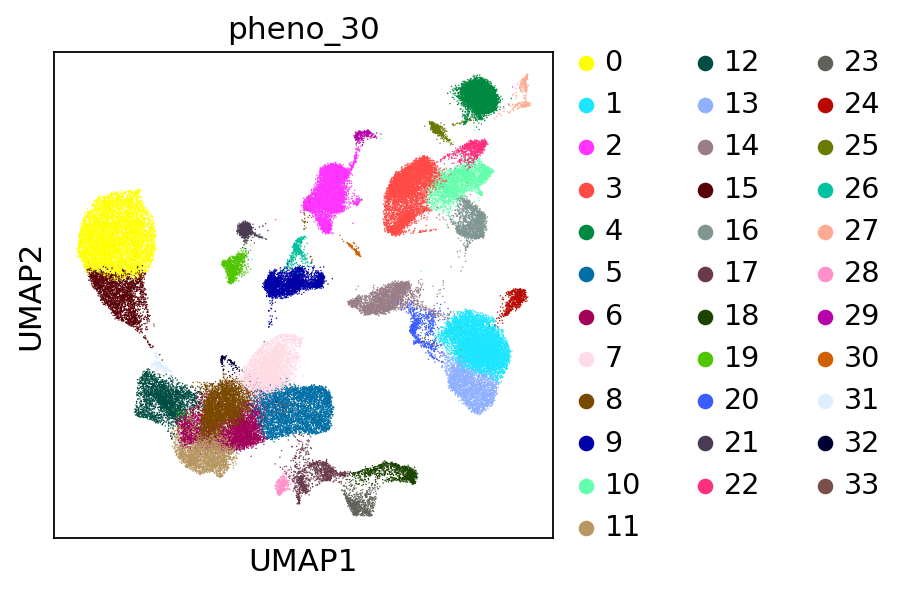

In [ ]:
sc.pl.umap(adata, color='pheno_30')

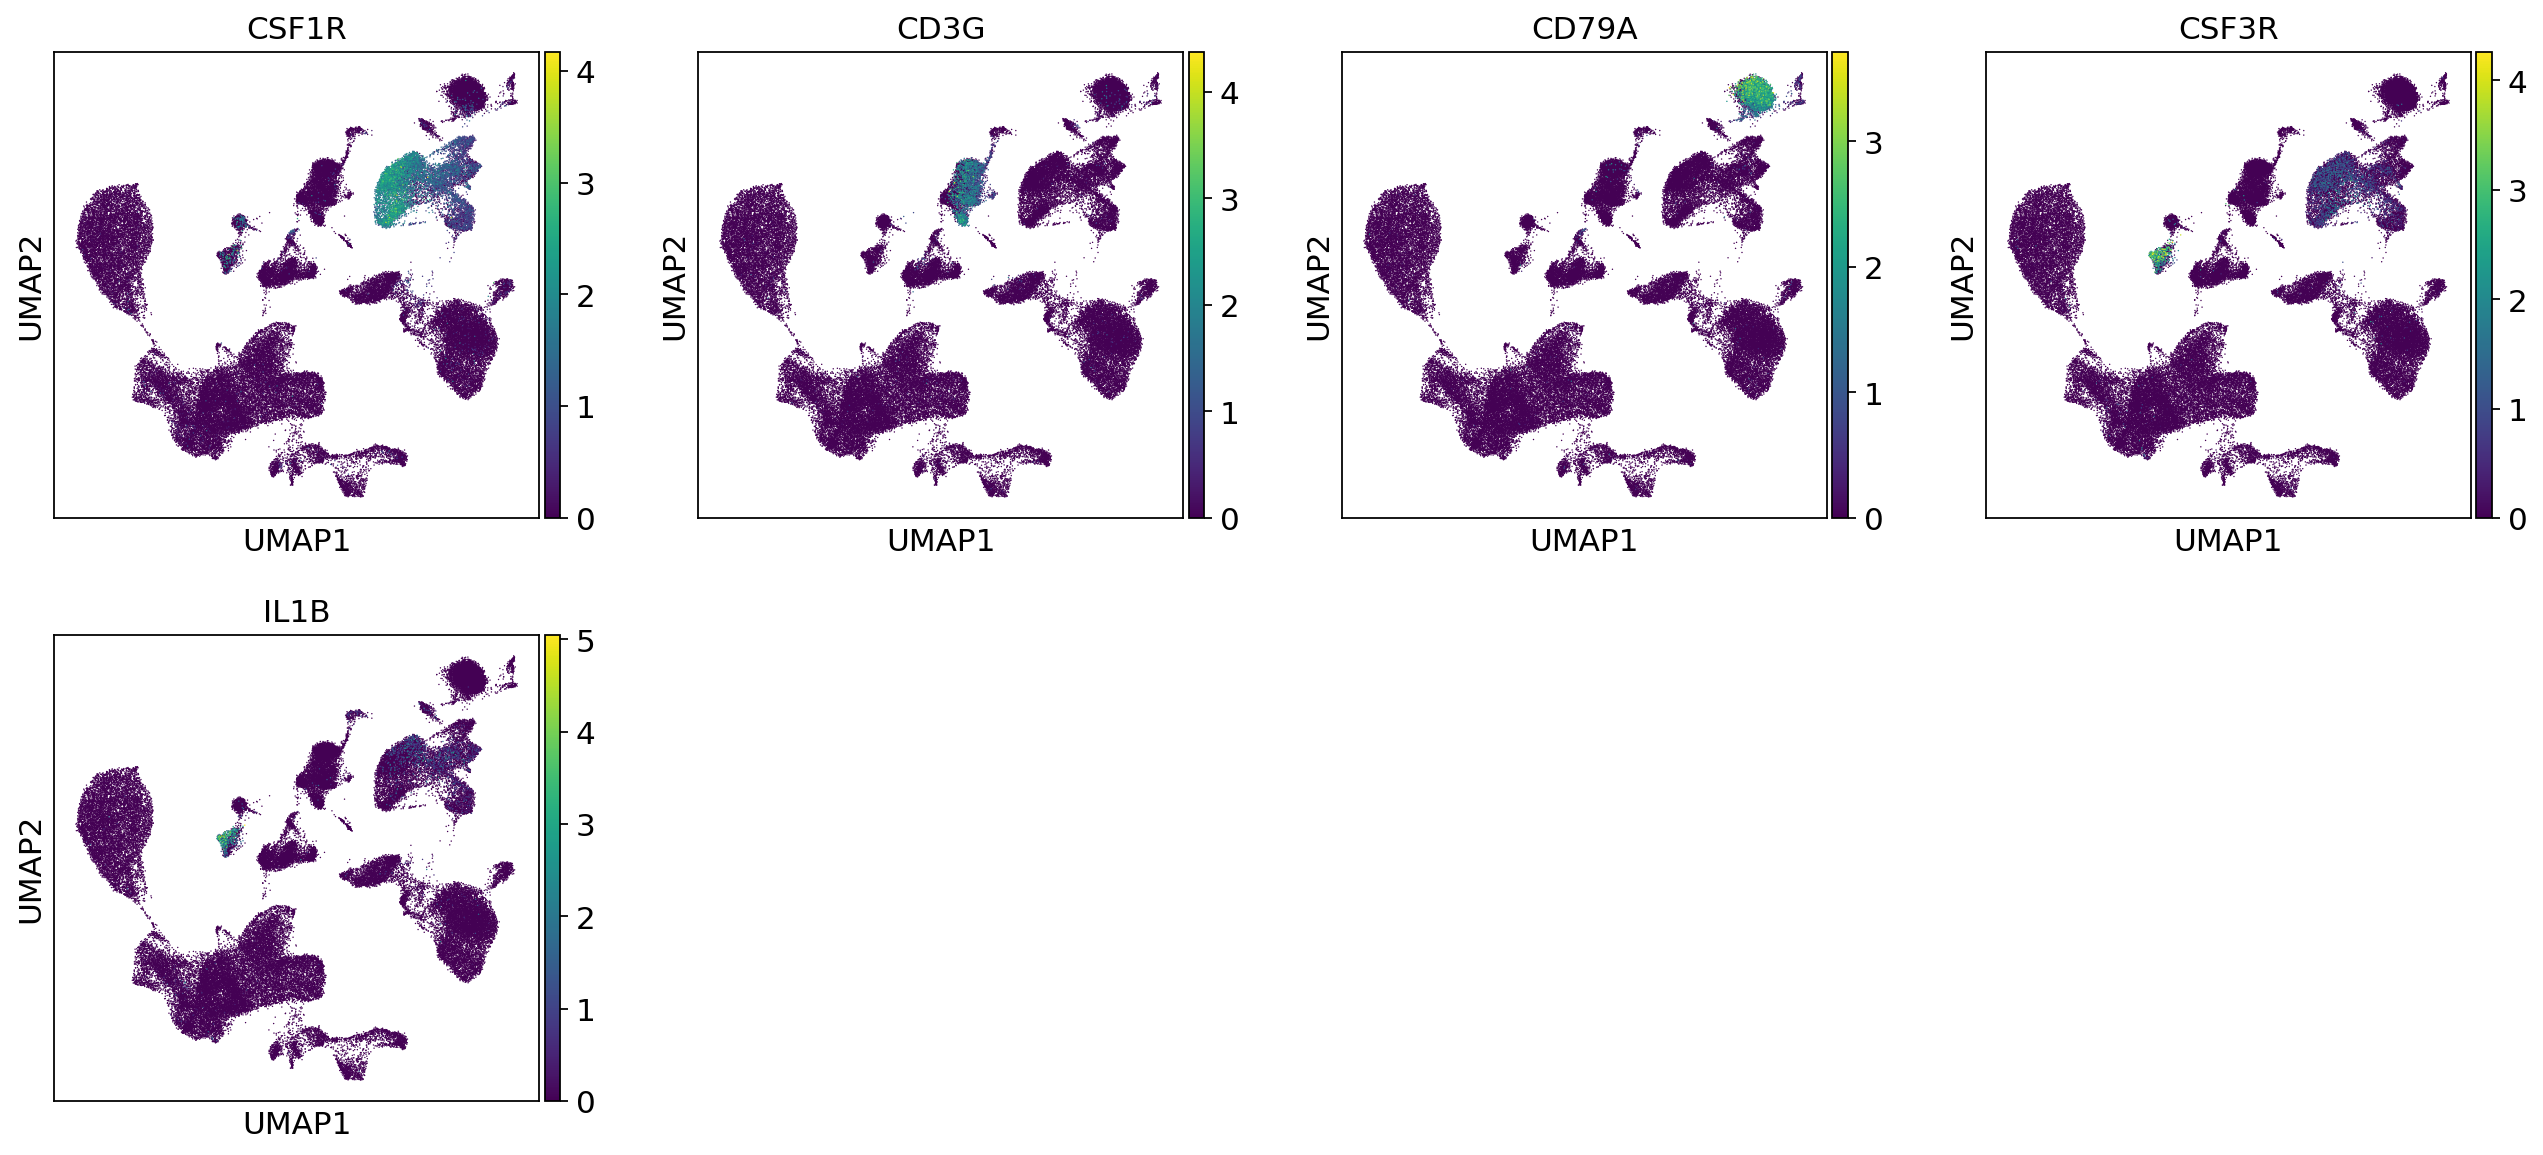

In [ ]:
sc.pl.umap(adata, color=['CSF1R', 'CD3G', 'CD79A', 'CSF3R', 'IL1B'])

### Subset macrophages and monocytes

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


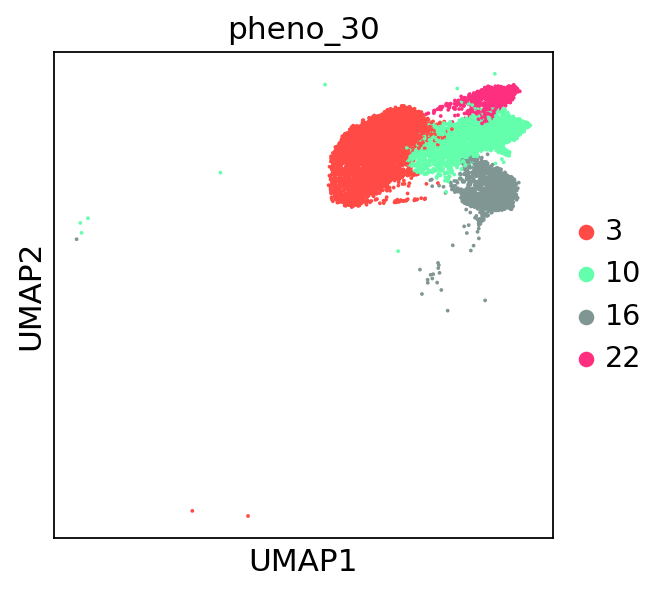

In [ ]:
adata_TAM = adata[ismember(adata.obs['pheno_30'], [3,10,16,22])[1]]
sc.pl.umap(adata_TAM, color='pheno_30')

Normalizing data
Log transform with pseudocount 1
Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes
Detecting inflection point with average smoothing window of 10 and epsilon 0.000010
Using 61 PCs that explain 33.51 percent variance


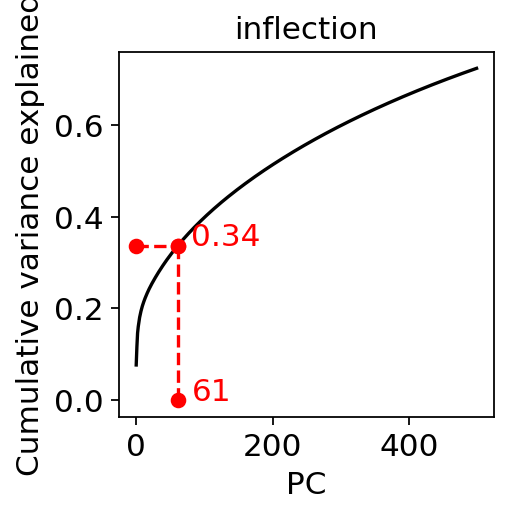

In [ ]:
adata_sub = adata_TAM.copy()
layer = 'raw'
size_factors = 'log_lib_size_%s_noExcluded' % (layer)
adata_sub.X = adata_sub.layers[layer].copy()
adata_sub = norm_log_transform(adata_sub, np.exp(adata_sub.obs[size_factors]), [])
sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG=3000, exclude_genes=adata_sub.var['excluded'], mode='scanpy', layer='raw')
sc.pp.pca(adata_sub, n_comps=500, use_highly_variable=True)
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'inflection')
adata_sub.uns['pca_inflection'] = selected_pcs

adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:adata_sub.uns['pca_inflection']].copy()
explained_var = np.sum(adata_sub.uns['pca']['variance_ratio'][:adata_sub.uns['pca_inflection']])
print("Using %d PCs that explain %.2f percent variance" % (adata_sub.obsm['X_pca'].shape[1], explained_var * 100))

2025-04-13 12:25:11.278706: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-13 12:25:11.966878: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-13 12:25:12.587044: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-13 12:25:12.587093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-13 12:25:12.650720: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

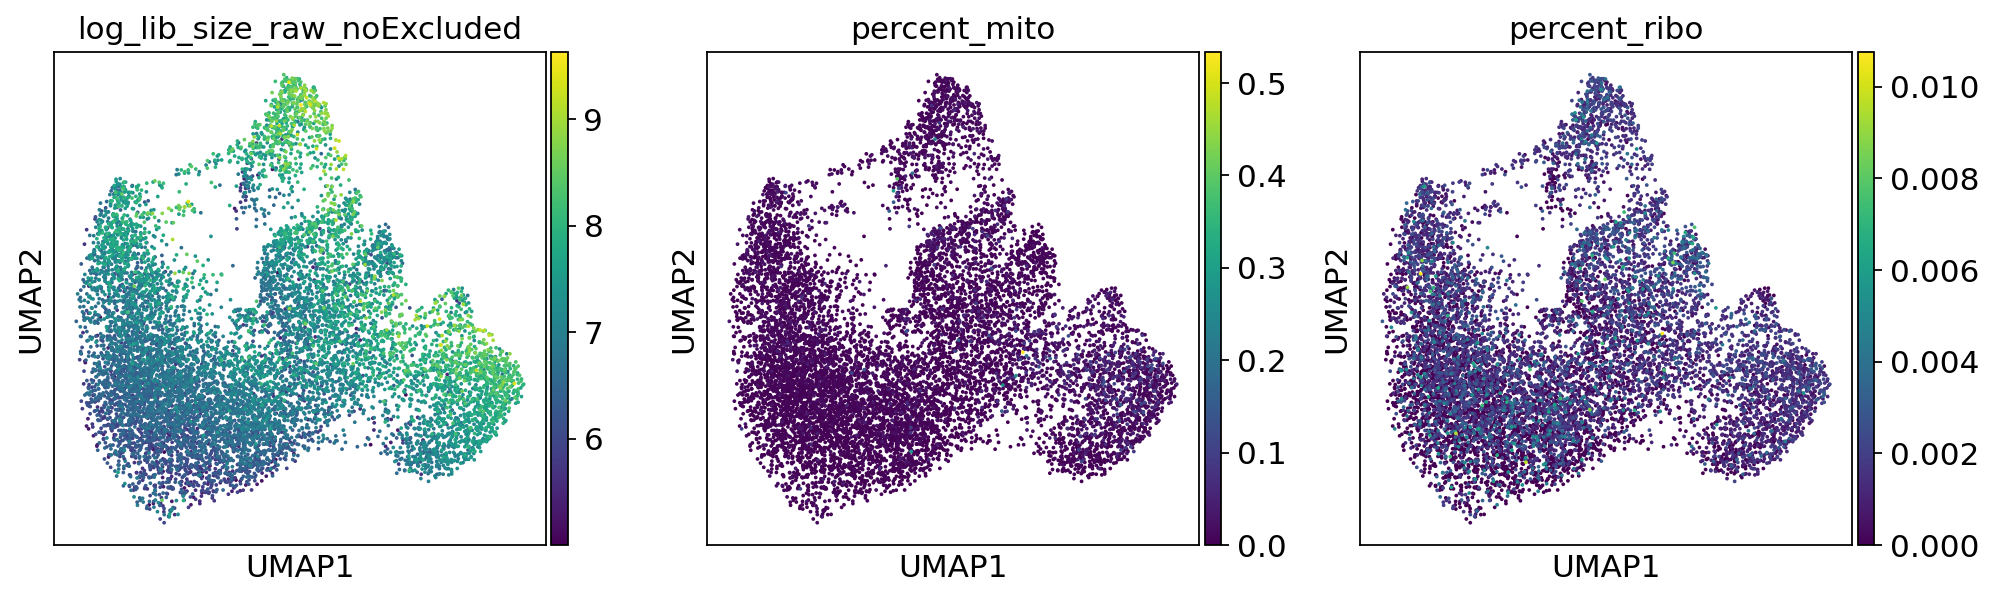

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.9083209037780762 seconds
Jaccard graph constructed in 8.271667242050171 seconds
Running Leiden optimization
Leiden completed in 6.418513536453247 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 19.961979866027832 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.5864071846008301 seconds
Jaccard graph constructed in 6.18084454536438 seconds
Running Leiden optimization
Leiden completed in 1.7906849384307861 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 12.631288528442383 seconds


In [ ]:
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)
sc.pl.umap(adata_sub, color=[size_factors, 'percent_mito', 'percent_ribo'])

communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo='leiden', copy = True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo='leiden', copy = True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])

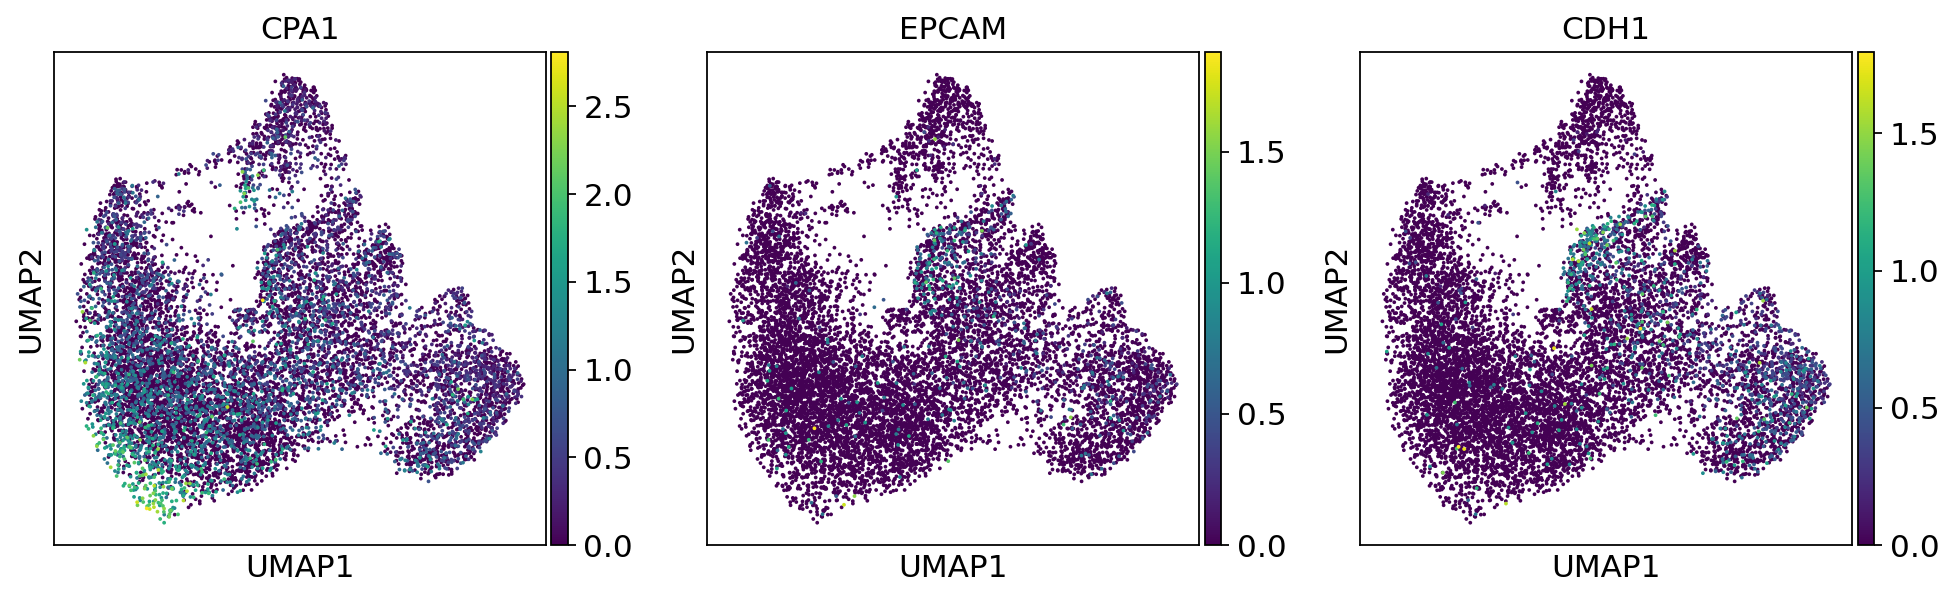

In [ ]:
sc.pl.umap(adata_sub, color=['CPA1', 'EPCAM', 'CDH1'])

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


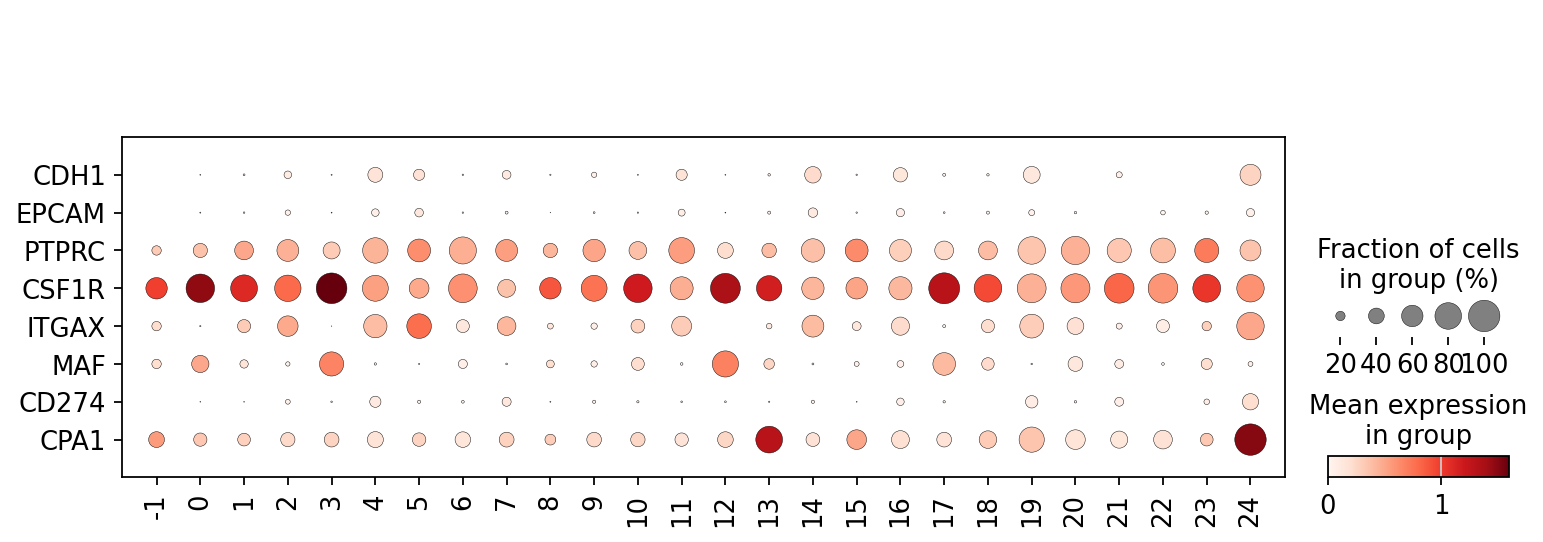

In [ ]:
sc.pl.dotplot(adata_sub, groupby = 'pheno_10', var_names = ['CDH1', 'EPCAM', 'PTPRC', 'CSF1R', 'ITGAX', 'MAF', 'CD274', 'CPA1'], swap_axes = True)

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


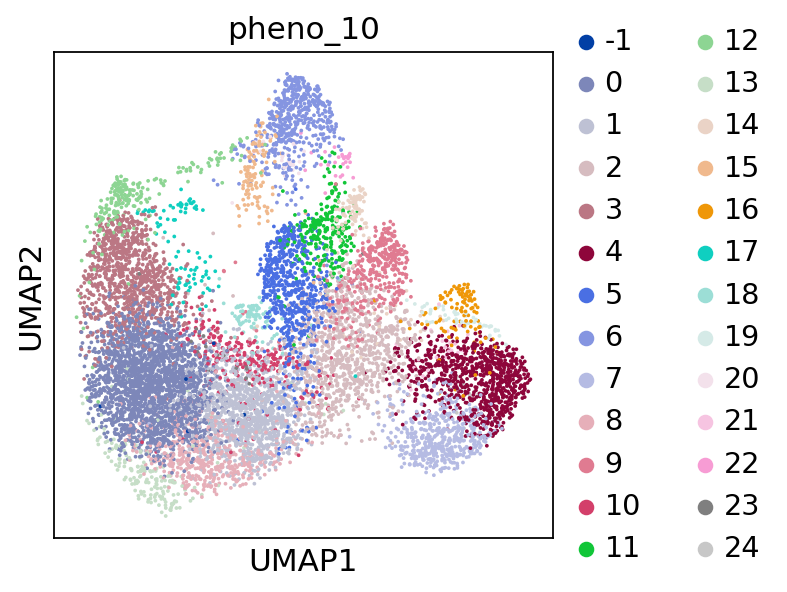

In [ ]:
sc.pl.umap(adata_sub, color='pheno_10')

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


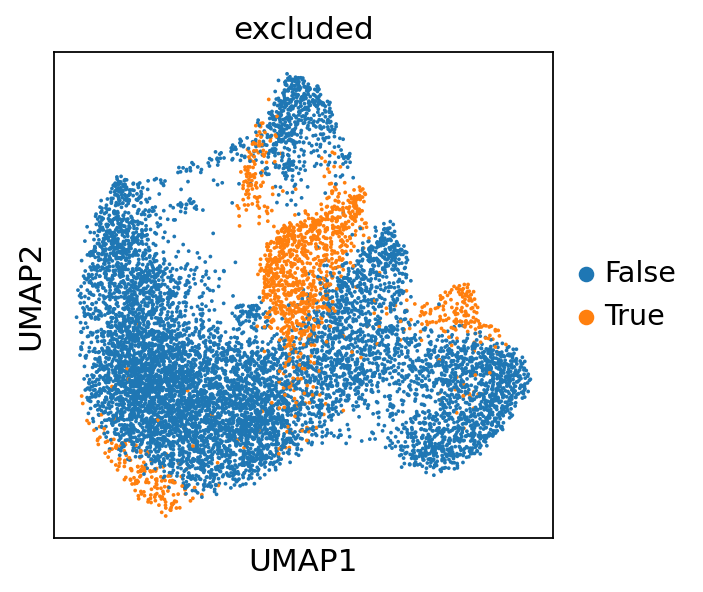

In [ ]:
adata_sub.obs['excluded'] = pd.Categorical(ismember(adata_sub.obs['pheno_10'], [13,24,19,15,14,11,16,5,11])[1])
sc.pl.umap(adata_sub, color='excluded')

In [ ]:
adata_sub = adata_sub[adata_sub.obs['excluded'] == False,:].copy()

Normalizing data
Log transform with pseudocount 1
Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes
Detecting inflection point with average smoothing window of 10 and epsilon 0.000010


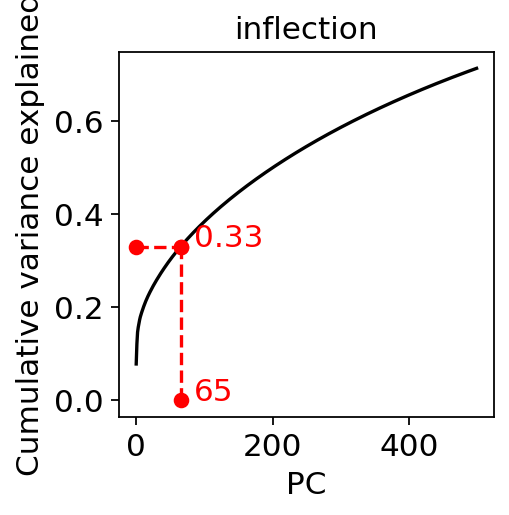

In [ ]:
layer = 'raw'
size_factors = 'log_lib_size_%s_noExcluded' % (layer)
adata_sub.X = adata_sub.layers[layer].copy()
adata_sub = norm_log_transform(adata_sub, np.exp(adata_sub.obs[size_factors]), [])
sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG=3000, exclude_genes=adata_sub.var['excluded'], mode='scanpy', layer='raw')
sc.pp.pca(adata_sub, n_comps=500, use_highly_variable=True)
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'inflection')
adata_sub.uns['pca_inflection'] = selected_pcs


Using 65 PCs that explain 32.83 percent variance


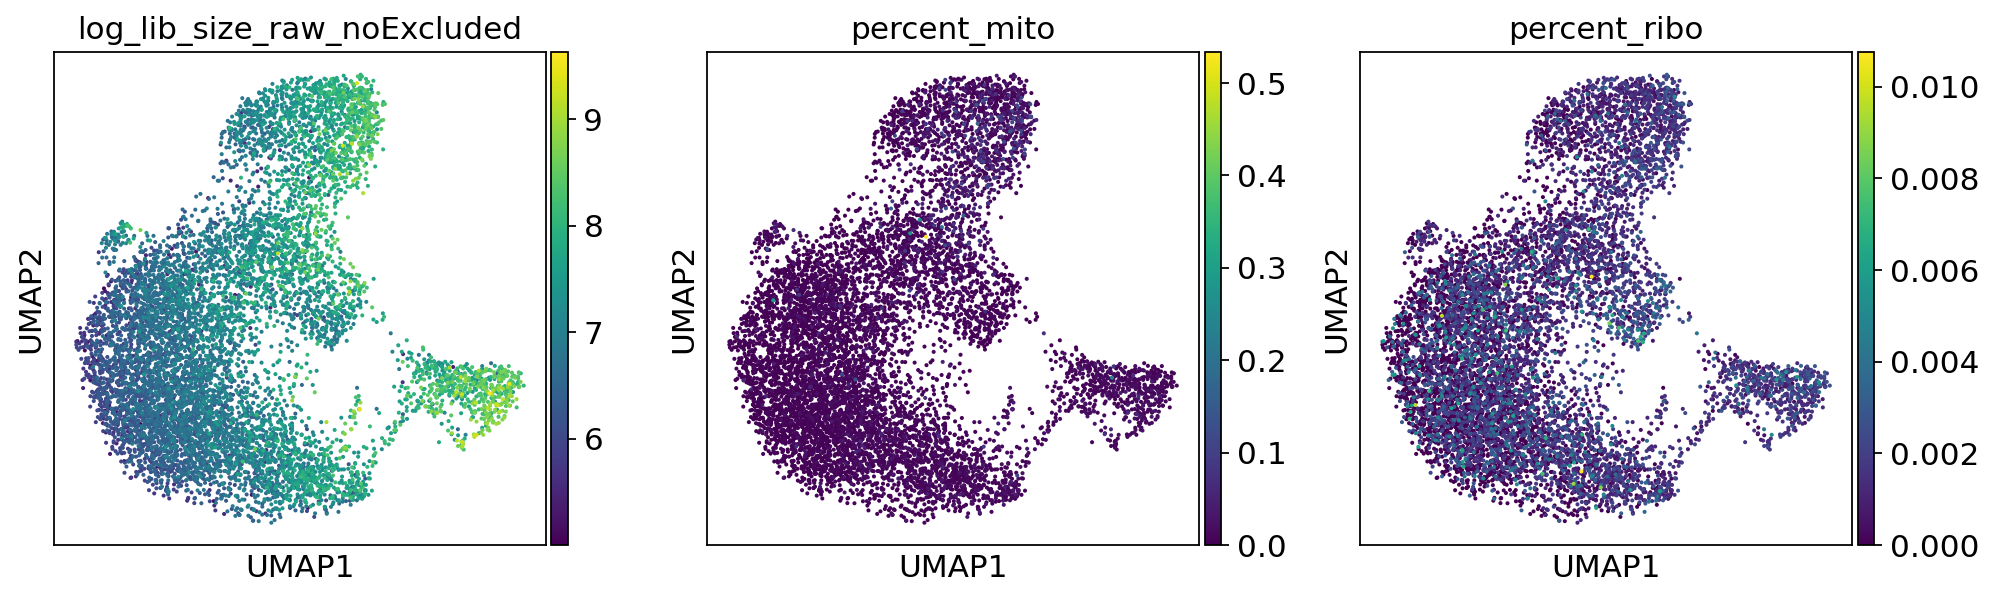

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.4572479724884033 seconds
Jaccard graph constructed in 8.279369831085205 seconds
Running Leiden optimization
Leiden completed in 4.709014177322388 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 18.150078773498535 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.47171640396118164 seconds
Jaccard graph constructed in 5.512327671051025 seconds
Running Leiden optimization
Leiden completed in 1.5570709705352783 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 11.764514684677124 seconds


In [ ]:
adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:adata_sub.uns['pca_inflection']].copy()
explained_var = np.sum(adata_sub.uns['pca']['variance_ratio'][:adata_sub.uns['pca_inflection']])
print("Using %d PCs that explain %.2f percent variance" % (adata_sub.obsm['X_pca'].shape[1], explained_var * 100))

sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)
sc.pl.umap(adata_sub, color=[size_factors, 'percent_mito', 'percent_ribo'])

communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo='leiden', copy = True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo='leiden', copy = True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])


In [ ]:
dm_res = getDiffusionComponents(adata_sub.obsp['distances'])
adata_sub.obsp['diffusion_operator'] = dm_res['T'].copy()
adata_sub.obsm['X_diff_comp'] = dm_res['EigenVectors'].to_numpy()[:,1:]
adata_sub.uns['diff_comp_eigenvalues'] = dm_res['EigenValues'].to_numpy()[1:]

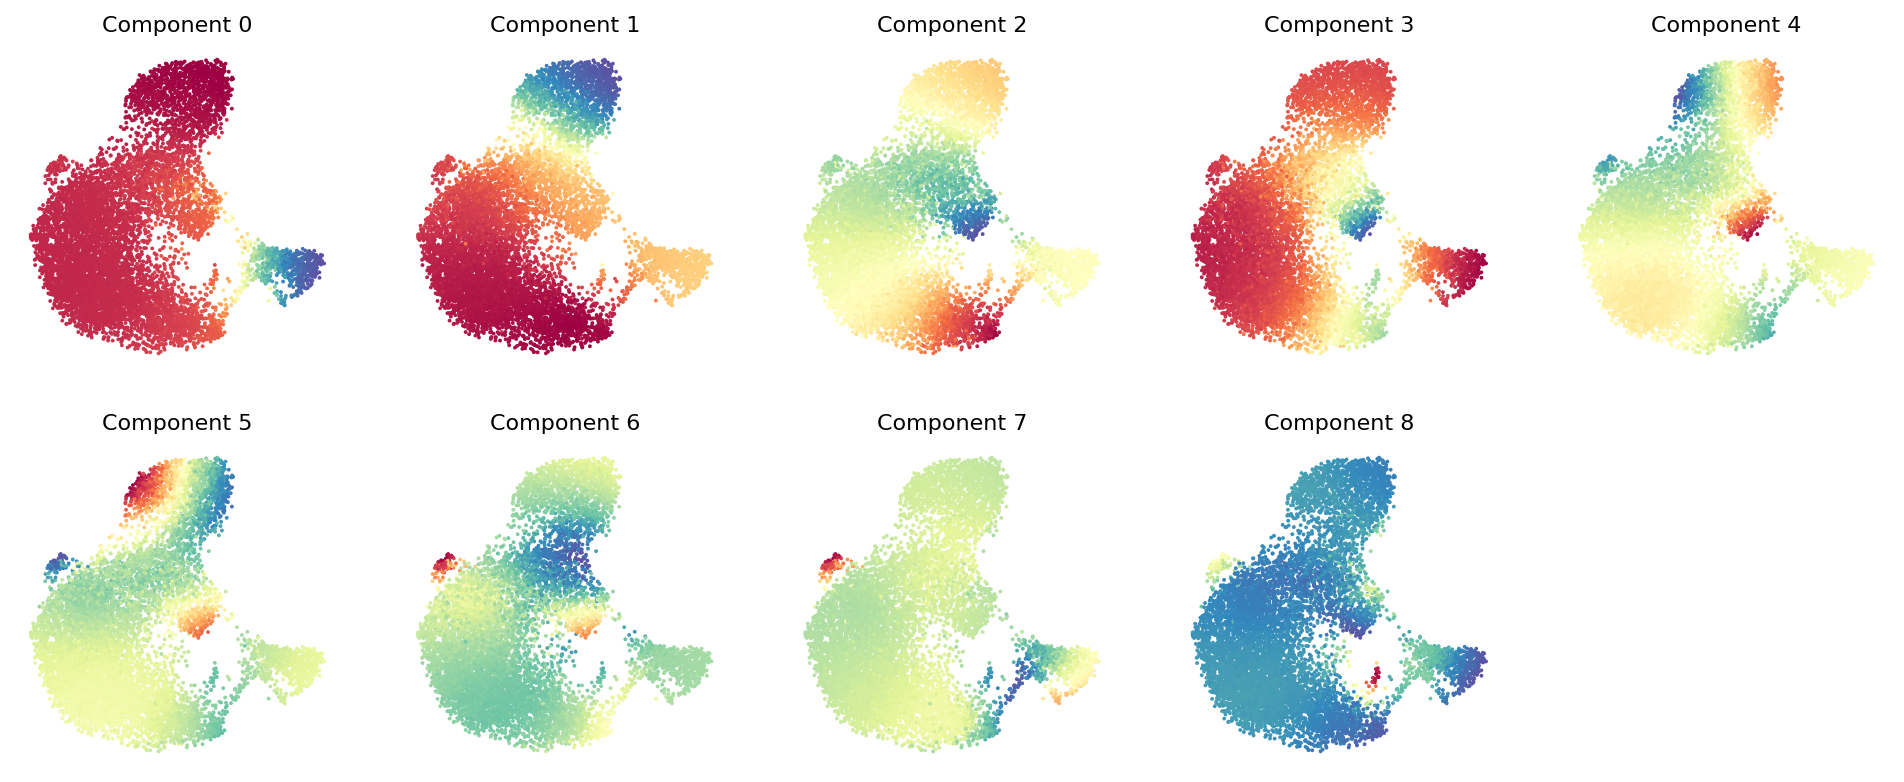

In [ ]:
plot_diffusion_components(adata_sub.obsm['X_umap'], adata_sub.obsm['X_diff_comp'])

In [ ]:
sc.write('../data/Reyes_FLEX_SUBSET_TAM_all__integrated.h5ad', adata = adata_sub)